# Task 4: General Health Query Chatbot

## Objective
Build a chatbot that answers general health-related questions using an LLM and Prompt Engineering.

In [22]:
!pip -q install pandas matplotlib seaborn transformers accelerate sentencepiece

**Import Required Libraries**

In [41]:
import pandas as pd
import numpy as np
import torch

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForCausalLM
import warnings
warnings.filterwarnings("ignore")

**Load dataset**

In [24]:
df = pd.read_csv("/content/drive/MyDrive/Healthcare Patient-Doctor Conversation Dataset (50K Samples).csv")

df.head()

,patient_input,doctor_response,age,gender,condition,symptom,duration,severity,intent,category
0,I am a 68-year-old Other experiencing severe c...,Your symptoms sound serious. It is strongly ad...,68,Other,Obesity,severe chest pain,for a few hours,severe,urgency,cardio
1,I have been having joint pain for a few hours....,Consider seeking medical advice if symptoms do...,7,Female,Diabetes,joint pain,for a few hours,moderate,advice,musculoskeletal
2,I have been having mild headache for a few hou...,"It may not be serious, but keep observing your...",17,Other,Thyroid Disorder,mild headache,for a few hours,mild,advice,neuro
3,My shortness of breath has been bothering me o...,Your symptoms sound serious. It is strongly ad...,31,Female,Thyroid Disorder,shortness of breath,on and off for a month,severe,urgency,respiratory
4,"Hello doctor, I feel persistent cough. I am 85...",Consider seeking medical advice if symptoms do...,85,Other,NaN,persistent cough,for a week,moderate,advice,respiratory


**Dataset Overview**

In [25]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

df.head()

Shape: (50000, 10)

Columns:
Index(['patient_input', 'doctor_response', 'age', 'gender', 'condition',
       'symptom', 'duration', 'severity', 'intent', 'category'],
      dtype='object')


,patient_input,doctor_response,age,gender,condition,symptom,duration,severity,intent,category
0,I am a 68-year-old Other experiencing severe c...,Your symptoms sound serious. It is strongly ad...,68,Other,Obesity,severe chest pain,for a few hours,severe,urgency,cardio
1,I have been having joint pain for a few hours....,Consider seeking medical advice if symptoms do...,7,Female,Diabetes,joint pain,for a few hours,moderate,advice,musculoskeletal
2,I have been having mild headache for a few hou...,"It may not be serious, but keep observing your...",17,Other,Thyroid Disorder,mild headache,for a few hours,mild,advice,neuro
3,My shortness of breath has been bothering me o...,Your symptoms sound serious. It is strongly ad...,31,Female,Thyroid Disorder,shortness of breath,on and off for a month,severe,urgency,respiratory
4,"Hello doctor, I feel persistent cough. I am 85...",Consider seeking medical advice if symptoms do...,85,Other,NaN,persistent cough,for a week,moderate,advice,respiratory


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   patient_input    50000 non-null  object
 1   doctor_response  50000 non-null  object
 2   age              50000 non-null  int64 
 3   gender           50000 non-null  object
 4   condition        42884 non-null  object
 5   symptom          50000 non-null  object
 6   duration         50000 non-null  object
 7   severity         50000 non-null  object
 8   intent           50000 non-null  object
 9   category         50000 non-null  object
dtypes: int64(1), object(9)
memory usage: 3.8+ MB


In [27]:
df.isnull().sum()

,0
patient_input,0
doctor_response,0
age,0
gender,0
condition,7116
symptom,0
duration,0
severity,0
intent,0
category,0


**Example Patient Questions**

In [28]:
df[['patient_input','doctor_response']].head(10)

,patient_input,doctor_response
0,I am a 68-year-old Other experiencing severe c...,Your symptoms sound serious. It is strongly ad...
1,I have been having joint pain for a few hours....,Consider seeking medical advice if symptoms do...
2,I have been having mild headache for a few hou...,"It may not be serious, but keep observing your..."
3,My shortness of breath has been bothering me o...,Your symptoms sound serious. It is strongly ad...
4,"Hello doctor, I feel persistent cough. I am 85...",Consider seeking medical advice if symptoms do...
5,I am a 24-year-old Other experiencing high fev...,This may require urgent medical attention. Ple...
6,"Hello doctor, I feel high fever. I am 65, Othe...",Your symptoms sound serious. It is strongly ad...
7,My skin rash has been bothering me on and off ...,"It may not be serious, but keep observing your..."
8,"Hello doctor, I feel high fever. I am 10, Male...",Your symptoms sound serious. It is strongly ad...
9,My shortness of breath has been bothering me f...,Your symptoms sound serious. It is strongly ad...


In [29]:
for i in range(5):

    print("Question",i+1)

    print(df["patient_input"][i])

    print()

Question 1
I am a 68-year-old Other experiencing severe chest pain for a few hours. What should I do?

Question 2
I have been having joint pain for a few hours. I am 7 years old and have Diabetes.

Question 3
I have been having mild headache for a few hours. I am 17 years old and have Thyroid Disorder.

Question 4
My shortness of breath has been bothering me on and off for a month. I have a history of Thyroid Disorder.

Question 5
Hello doctor, I feel persistent cough. I am 85, Other. Any advice?



In [30]:
for i in range(5):

    print("Answer",i+1)

    print(df["doctor_response"][i])

    print()

Answer 1
Your symptoms sound serious. It is strongly advised to seek immediate medical care.

Answer 2
Consider seeking medical advice if symptoms do not improve within a few days.

Answer 3
It may not be serious, but keep observing your symptoms and maintain a healthy routine.

Answer 4
Your symptoms sound serious. It is strongly advised to seek immediate medical care.

Answer 5
Consider seeking medical advice if symptoms do not improve within a few days.



**Categories Distribution**

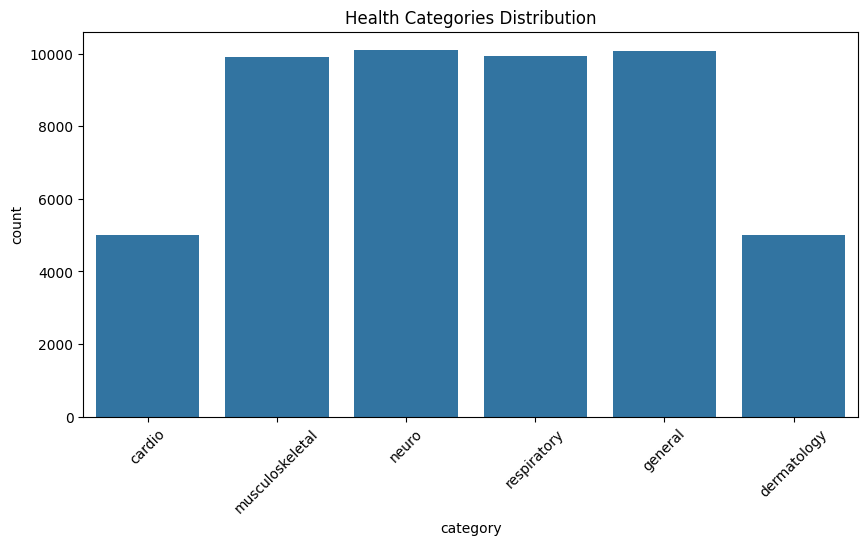

In [31]:
if 'category' in df.columns:

    plt.figure(figsize=(10,5))

    sns.countplot(
        x=df['category']
    )

    plt.xticks(rotation=45)

    plt.title("Health Categories Distribution")

    plt.show()

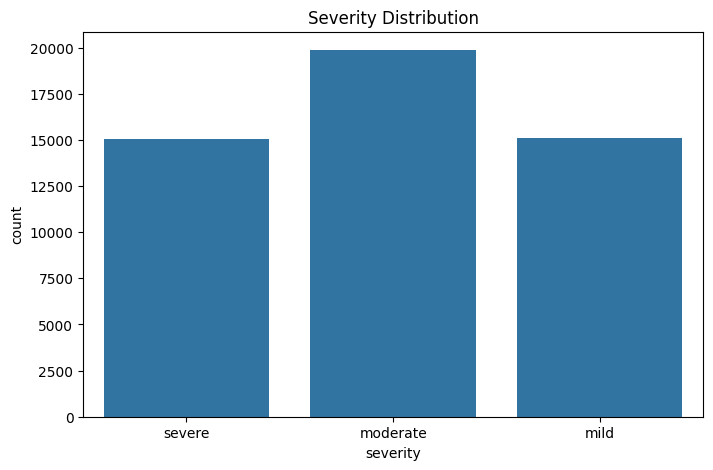

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="severity")
plt.title("Severity Distribution")
plt.show()

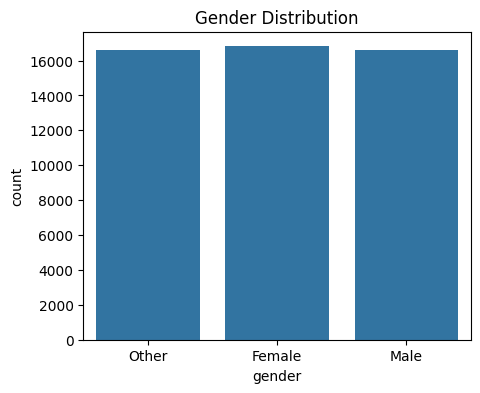

In [33]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")
plt.show()

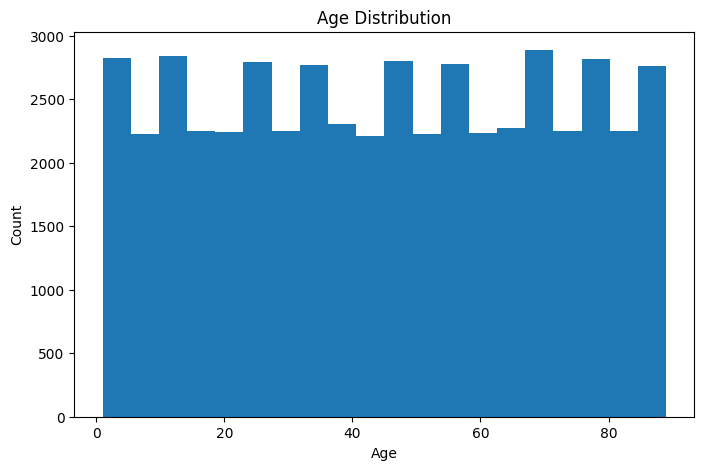

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

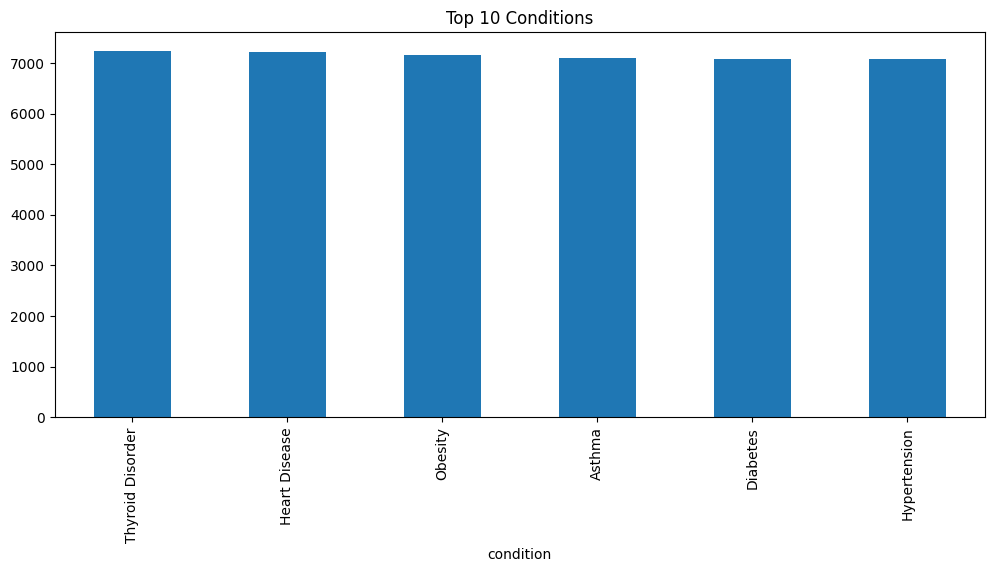

In [35]:
plt.figure(figsize=(12,5))

df["condition"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Conditions")

plt.show()

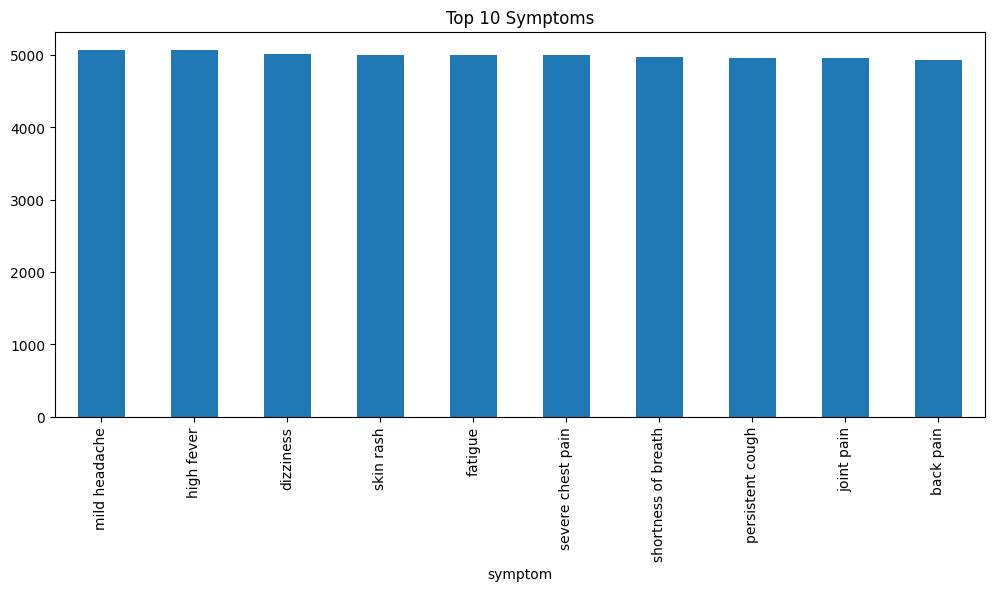

In [36]:
plt.figure(figsize=(12,5))

df["symptom"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Symptoms")

plt.show()

**Load ChatBot Model**

In [42]:
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"


tokenizer = AutoTokenizer.from_pretrained(
    model_name
)


model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [43]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cpu


**Safety Filter**

In [44]:
danger_words = [
    "suicide",
    "kill myself",
    "overdose",
    "self harm",
    "harm myself"
]

**Chatbot Function with Prompt Engineering**

In [45]:
def health_chatbot(question):

    # Safety filter

    for word in danger_words:

        if word in question.lower():

            return """
I am sorry you are feeling this way.

Please contact a trusted person or a mental health professional.
If you are in immediate danger, contact emergency services.
"""


    prompt = f"""
<|system|>

You are a helpful medical assistant.

Rules:
- Give general health information only.
- Do not diagnose diseases.
- Do not prescribe medicines.
- Encourage users to consult doctors.
- Use simple and friendly language.

<|user|>

{question}

<|assistant|>
"""


    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)


    output = model.generate(
        **inputs,
        max_new_tokens=120,
        temperature=0.7,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )


    response = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )


    answer = response.split("<|assistant|>")[-1]


    return answer.strip()

**Test the Chatbot**

In [46]:
print(
    health_chatbot(
        "What causes sore throat?"
    )
)

[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The causes of sore throat can vary depending on the underlying conditions. Here are a few common causes:

1. Laryngitis: This is an inflammation of the voice box (larynx) that causes hoarseness and difficulty in speaking.

2. Pharyngitis: This is a infection of the pharynx (the throat), usually caused by a viral infection.

3. Throat cancer: This is a cancer that affects the throat.

4. Epiglottis: This


In [47]:
print(
    health_chatbot(
        "Is paracetamol safe for children?"
    )
)

[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Yes, paracetamol is safe for children. Paracetamol is an over-the-counter pain reliever and fever reducer that is commonly used to treat mild to moderate pain, fever, and inflammation. It has no known risks for children under 2 years of age. Paracetamol is known to be safe for children, and it has been used safely for more than 50 years without reported adverse effects. However, it is always wise to check with a doctor or a healthcare professional if you are


In [48]:
print(
    health_chatbot(
        "How can I reduce stress?"
    )
)

[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


I am not able to feel stress or provide specific stress-reducing tips. However, here are some general tips that may help:

1. Take breaks: take short, frequent breaks throughout the day to help you recharge and reduce stress.

2. Exercise: regular exercise can help improve your mood and reduce stress.

3. Practice relaxation techniques: yoga, meditation, or deep breathing can help you relax and reduce stress.

4. Stay active: engaging in activities that you enjoy can help reduce stress, such


**Interactive Chatbot**

In [49]:
while True:

    user_question = input(
        "\nAsk Health Question (type exit to stop): "
    )


    if user_question.lower()=="exit":

        print("Chat ended.")

        break


    response = health_chatbot(
        user_question
    )


    print("\nAssistant:")
    print(response)


Ask Health Question (type exit to stop): is paracetamol better for children?


[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Assistant:
Yes, paracetamol is generally safe and effective for treating minor injuries, fever, and headaches in children. Paracetamol is available over the counter without a prescription. However, if you are not sure if paracetamol is safe for your child, it is always best to consult a healthcare professional.

Ask Health Question (type exit to stop): exit
Chat ended.


**Results and Findings**

1. A health chatbot was successfully developed.
2. Prompt engineering was used to control response behavior.
3. Safety filters were added to avoid harmful advice.
4. The chatbot provides friendly and general health information.

**Conclusion**

A prompt-engineering-based healthcare chatbot was built using a pre-trained language model. Safety measures were incorporated to reduce the risk of harmful responses while providing useful health information.